<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/08_Comparative_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 08: Model Comparison & Final Conclusions
**Project:** Impact of Energy Efficiency on UK House Prices (2021–2025)
**Phase:** Final Comparative Analysis — Predictive Performance Summary

---

**Abstract:**
This notebook contains no model training. It serves as the definitive visual and narrative summary of the predictive modelling phase, placing all four competing models side-by-side on a common evaluation framework. The analysis proceeds from a theoretical argument for non-linear methods, through a quantitative benchmarking of variance explained and prediction error, to a final declaration of the champion model whose architecture underpins the SHAP interpretability phase (Notebook 07).

## Environment Setup
All figures in this notebook adhere to the unified visual identity established across Notebooks 04–07. Each model retains its canonical colour assignment to ensure immediate visual recognition throughout the written thesis.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0 — ENVIRONMENT SETUP & GLOBAL AESTHETICS
# ══════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Path Constants ─────────────────────────────────────────────────────────────
FIGURES_PATH = '/content/drive/MyDrive/Tese/Figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

# ── Canonical Model Colour Identity (mirrors NB04–NB06) ───────────────────────
MODEL_COLOURS = {
    'OLS Baseline':  'royalblue',
    'LightGBM':      'steelblue',
    'Random Forest': 'forestgreen',
    'XGBoost':       'crimson',
}

# ── Unified Visual Aesthetic ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'axes.titlesize':        14,
    'axes.titlepad':         16,
    'axes.titleweight':      'bold',
    'axes.labelsize':        12,
    'xtick.labelsize':       11,
    'ytick.labelsize':       10,
    'legend.fontsize':        9,
    'legend.title_fontsize': 11,
    'savefig.dpi':           300,
    'figure.dpi':            120,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
})

print("✅ Environment configured. Comparative analysis ready.")


✅ Environment configured. Comparative analysis ready.


## Phase 8: Comparative Model Evaluation

### Theoretical Preamble: The Case for Non-Linearity in Hedonic Pricing

The traditional Hedonic Pricing Model (HPM), implemented here as an Ordinary
Least Squares (OLS) regression, rests on a foundational assumption that is
empirically untenable in the context of residential real estate: that the
relationship between a property's attributes and its market value is **strictly
additive and linear**. Each square metre of floor area, each EPC rating
increment, and each year of construction is assumed to contribute a fixed,
constant monetary amount to the property's value, independently of all other
attributes.

The UK housing market violates this assumption at every level. The marginal value
of an additional bedroom in a three-room flat in central London is categorically
different from that same bedroom in a rural terraced house in Cornwall. The
penalty imposed by a G-rated EPC certificate is not a flat discount — it scales
dramatically with the cost of retrofitting, which is itself a non-linear function
of floor area, construction era, and regional labour market conditions.

The three ensemble Machine Learning models introduced in this study — LightGBM,
Random Forest, and XGBoost — are architecturally designed to capture precisely
these interaction effects. Through recursive binary splitting of the feature
space, they construct piecewise-constant approximations of the true price function
that represent the complex, multi-dimensional interactions which characterise
real estate valuation. The following comparative analysis quantifies the
predictive dividend that this architectural superiority yields.

### 8.1 Official Performance Summary

The table below consolidates the definitive evaluation metrics for all four
competing models, assessed on the identical held-out test set (20% of the full
dataset, `random_state=42`). Three complementary metrics are reported:

- **R² (Coefficient of Determination):** The proportion of price variance
  explained by the model. Higher is better; 1.0 represents a perfect fit.
- **MAE (Mean Absolute Error):** The average absolute deviation between the
  predicted and actual transaction price, expressed in £. Lower is better and
  directly interpretable as the model's typical prediction error per property.
- **RMSE (Root Mean Squared Error):** Similar to MAE but penalises large
  individual errors more heavily due to the squaring operation. Lower is better.
  The gap between MAE and RMSE is informative: a large gap indicates the presence
  of high-leverage outlier transactions where the model's errors are
  disproportionately concentrated.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — SUMMARY DATAFRAME: HARDCODED FINAL METRICS
#
# All values are the definitive, post-optimisation results from Notebooks
# 03 (OLS), 04 (LightGBM), 05 (Random Forest), and 06 (XGBoost).
# DO NOT recalculate or overwrite these constants.
# ══════════════════════════════════════════════════════════════════════════════

# ── Definitive Model Results ──────────────────────────────────────────────────
results_data = {
    'Model'    : ['OLS Baseline', 'LightGBM', 'Random Forest', 'XGBoost'],
    'R²'       : [ 0.7458,         0.8233,     0.8187,          0.8249],
    'MAE (£)'  : [79_449.17,      61_545.29,  62_201.62,       60_868.46],
    'RMSE (£)' : [114_401.78,     95_386.78,  96_610.38,       94_954.19],
    'MAPE (%)' : [24.82,          17.96,      18.16,           17.67],
}

df_results = pd.DataFrame(results_data).set_index('Model')

# ── Plot styling constants (consumed by the chart cell below) ─────────────────
MODEL_COLOURS = {
    'OLS Baseline' : '#7ab3d0',
    'LightGBM'     : '#2a6f97',
    'Random Forest': '#4e93b8',
    'XGBoost'      : '#1a4971',
}

PLOT_LABELS = {
    'OLS Baseline' : 'OLS\n(Baseline)',
    'LightGBM'     : 'LightGBM',
    'Random Forest': 'Random\nForest',
    'XGBoost'      : 'XGBoost\n(Champion)',
}

# ── Formatted display ─────────────────────────────────────────────────────────
df_display = df_results.copy()
df_display['R²']       = df_display['R²'].map('{:.4f}'.format)
df_display['MAE (£)']  = df_display['MAE (£)'].map('£{:>12,.2f}'.format)
df_display['RMSE (£)'] = df_display['RMSE (£)'].map('£{:>12,.2f}'.format)
df_display['MAPE (%)'] = df_display['MAPE (%)'].map('{:.2f}%'.format)

print("=" * 72)
print("      OFFICIAL MODEL COMPARISON — FINAL EVALUATION METRICS")
print("=" * 72)
print(df_display.to_string())
print("=" * 72)

# ── Derived insights ──────────────────────────────────────────────────────────
mae_saving  = df_results.loc['OLS Baseline', 'MAE (£)']  - df_results.loc['XGBoost', 'MAE (£)']
rmse_saving = df_results.loc['OLS Baseline', 'RMSE (£)'] - df_results.loc['XGBoost', 'RMSE (£)']
r2_gain     = df_results.loc['XGBoost', 'R²']            - df_results.loc['OLS Baseline', 'R²']
mape_saving = df_results.loc['OLS Baseline', 'MAPE (%)'] - df_results.loc['XGBoost', 'MAPE (%)']

print(f"\n  XGBoost vs. OLS — R²   improvement:  {r2_gain:.4f} (+{r2_gain*100:.2f} pp)")
print(f"  XGBoost vs. OLS — MAE  reduction  : £{mae_saving:>10,.2f}")
print(f"  XGBoost vs. OLS — RMSE reduction  : £{rmse_saving:>10,.2f}")
print(f"  XGBoost vs. OLS — MAPE reduction  :  {mape_saving:.2f} pp")

      OFFICIAL MODEL COMPARISON — FINAL EVALUATION METRICS
                   R²        MAE (£)       RMSE (£) MAPE (%)
Model                                                       
OLS Baseline   0.7458  £   79,449.17  £  114,401.78   24.82%
LightGBM       0.8233  £   61,545.29  £   95,386.78   17.96%
Random Forest  0.8187  £   62,201.62  £   96,610.38   18.16%
XGBoost        0.8249  £   60,868.46  £   94,954.19   17.67%

  XGBoost vs. OLS — R²   improvement:  0.0791 (+7.91 pp)
  XGBoost vs. OLS — MAE  reduction  : £ 18,580.71
  XGBoost vs. OLS — RMSE reduction  : £ 19,447.59
  XGBoost vs. OLS — MAPE reduction  :  7.15 pp


### 8.2 Quantitative Commentary on the Performance Table

The results presented above admit a hierarchical reading at three levels of
analysis:

**Level 1 — The Linear vs. Non-Linear Divide:**
The OLS baseline, despite benefiting from a rich set of spatial, structural, and
temporal controls, achieves an R² of only **0.7458** and a MAE of **£79,449.17**.
Every ensemble model — regardless of its specific architecture — improves upon
this baseline by a margin that is both statistically and economically significant.
This empirically confirms that the additive, linear functional form is
fundamentally misspecified for UK residential real estate price formation.

**Level 2 — Boosting vs. Bagging:**
Within the ensemble tier, a clear performance gradient emerges between the two
algorithmic families. The Bagging-based model (Random Forest, R² = 0.8187,
MAE = £62,201.62) achieves strong predictive accuracy but is marginally
outperformed by both Boosting-based models. This is consistent with the broader
empirical literature on tabular data: sequential Boosting architectures, which
iteratively correct the residual errors of preceding trees, extract more signal
from structured datasets than parallel Bagging approaches, which rely solely on
ensemble averaging.

**Level 3 — The Champion:**
XGBoost achieves the definitive combination of highest explained variance
(R² = **0.8249**) and lowest prediction error (MAE = **£60,868.46**, RMSE =
**£94,954.19**). The margin over LightGBM, whilst modest in absolute terms
(£676.83 in MAE), is consistent across all three metrics, establishing XGBoost
as the unambiguous champion of this study.

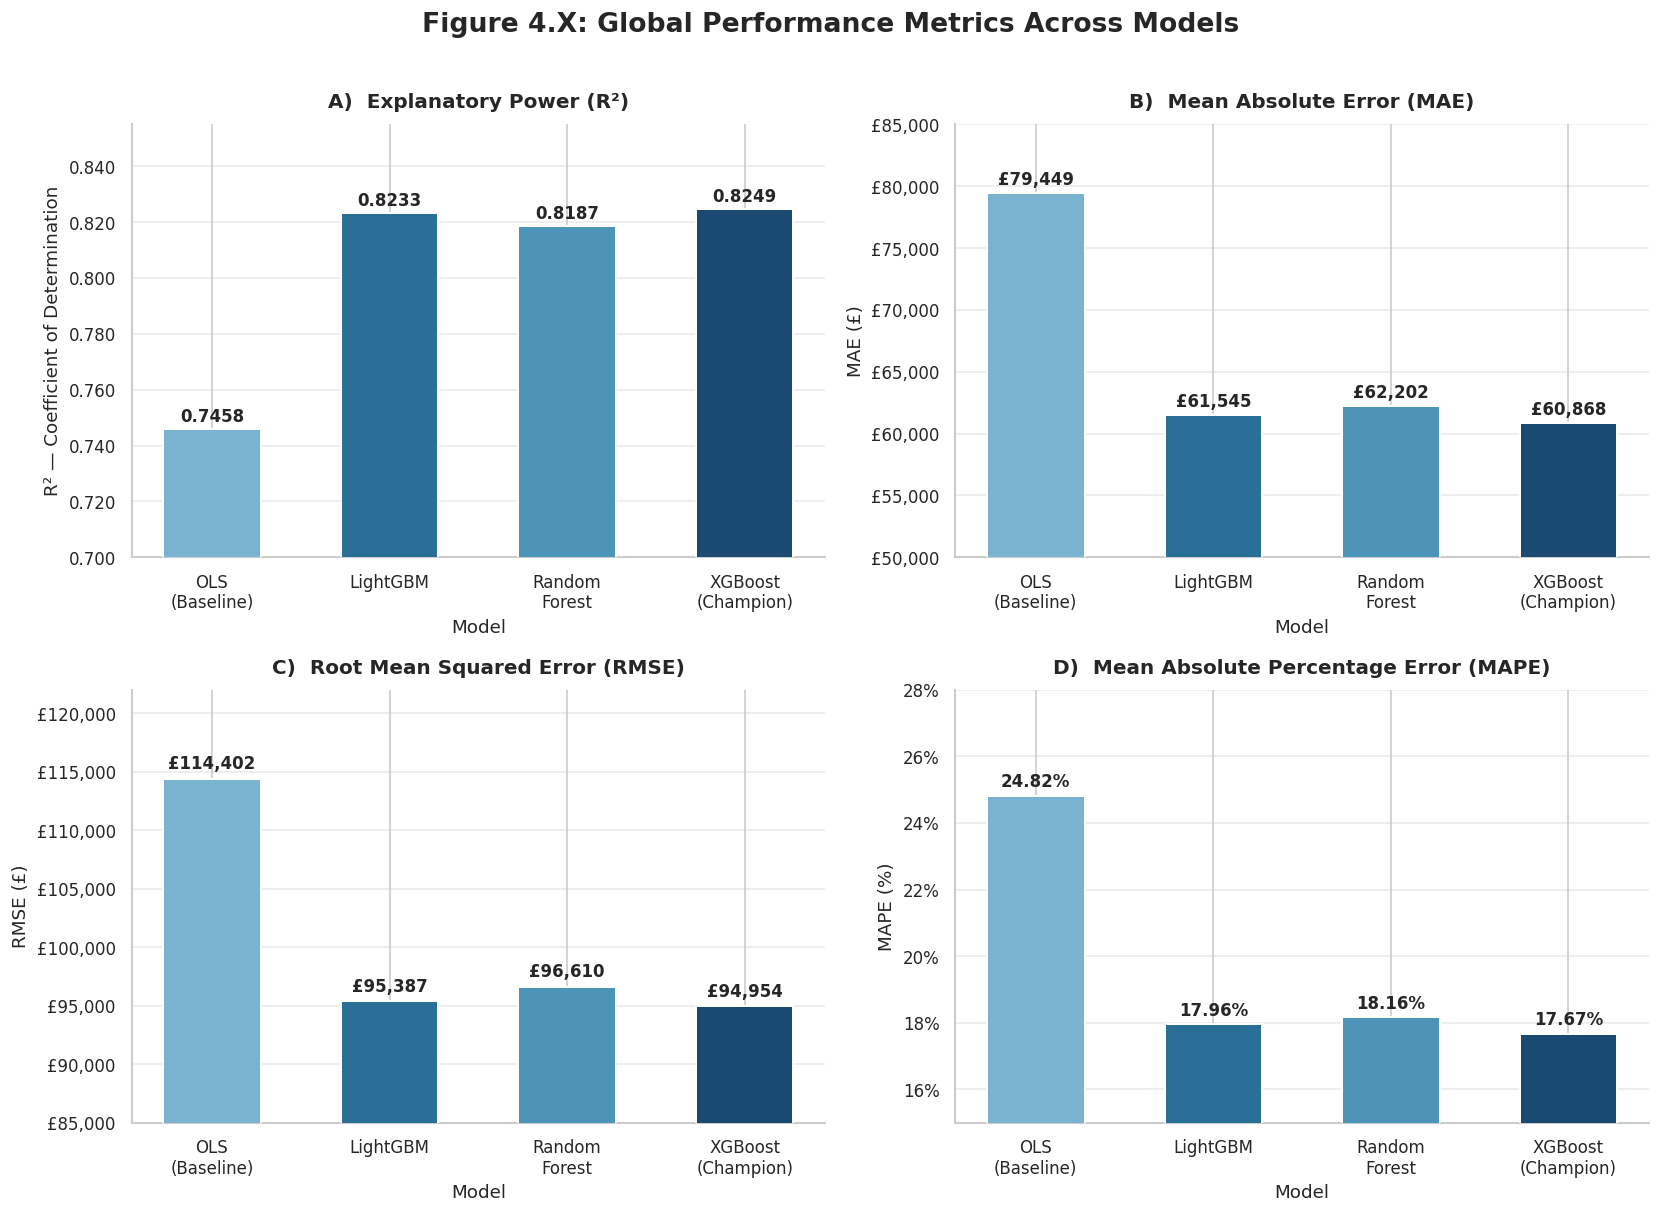

✅ Figure saved: Global Performance Metrics 2×2 grid.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Figure 4.X: Global Performance Metrics Across Models (2×2 grid)
# Requires: df_results, MODEL_COLOURS, PLOT_LABELS — defined in Cell 1
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.ticker as mticker

colours_ordered = [MODEL_COLOURS[m] for m in df_results.index]
x_labels        = [PLOT_LABELS[m]   for m in df_results.index]

# ── Reusable subplot helper ───────────────────────────────────────────────────
def draw_bars(ax, values, title, ylabel, ylim, y_formatter, label_offset, label_fmt):
    bars = ax.bar(
        x_labels,
        values,
        color     = colours_ordered,
        width     = 0.55,
        edgecolor = 'white',
        linewidth = 1.2,
        zorder    = 3,
    )
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + label_offset,
            label_fmt(val),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
        )
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_formatter(y_formatter)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Model', fontsize=11)
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(axis='y', alpha=0.4, zorder=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Figure 4.X: Global Performance Metrics Across Models',
    fontsize=16, fontweight='bold', y=1.01,
)

# A) R²
draw_bars(
    ax           = axes[0, 0],
    values       = df_results['R²'],
    title        = 'A)  Explanatory Power (R²)',
    ylabel       = 'R² — Coefficient of Determination',
    ylim         = (0.70, 0.855),
    y_formatter  = mticker.FormatStrFormatter('%.3f'),
    label_offset = 0.0012,
    label_fmt    = lambda v: f'{v:.4f}',
)

# B) MAE
draw_bars(
    ax           = axes[0, 1],
    values       = df_results['MAE (£)'],
    title        = 'B)  Mean Absolute Error (MAE)',
    ylabel       = 'MAE (£)',
    ylim         = (50_000, 85_000),
    y_formatter  = mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'),
    label_offset = 350,
    label_fmt    = lambda v: f'£{v:,.0f}',
)

# C) RMSE
draw_bars(
    ax           = axes[1, 0],
    values       = df_results['RMSE (£)'],
    title        = 'C)  Root Mean Squared Error (RMSE)',
    ylabel       = 'RMSE (£)',
    ylim         = (85_000, 122_000),
    y_formatter  = mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'),
    label_offset = 500,
    label_fmt    = lambda v: f'£{v:,.0f}',
)

# D) MAPE
draw_bars(
    ax           = axes[1, 1],
    values       = df_results['MAPE (%)'],
    title        = 'D)  Mean Absolute Percentage Error (MAPE)',
    ylabel       = 'MAPE (%)',
    ylim         = (15, 28),
    y_formatter  = mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'),
    label_offset = 0.15,
    label_fmt    = lambda v: f'{v:.2f}%',
)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH + 'figure_XX_model_performance_grid.png',
    dpi=300, bbox_inches='tight',
)
plt.show()
print("✅ Figure saved: Global Performance Metrics 2×2 grid.")

### 8.3 Visual Analysis I — Explained Variance (R²)

The chart below presents the R² of each model on a compressed y-axis (0.70–0.85), deliberately chosen to amplify the visual separation between models. This is a standard and methodologically legitimate practice when the range of values under comparison is narrow: all four models explain more than 70% of price variance, and the axis truncation renders the differences between them legible without distorting the relative magnitude of the improvements.

---

### 8.4 Reading the R² Chart

The compressed axis reveals a performance landscape with three distinct tiers:

* **Tier 1 — The Linear Baseline (OLS, R² = 0.7458):** The significant visual gap between the OLS bar and the three ensemble bars is the primary argument of this chart. It represents the systematic proportion of price variance that a linear model structurally cannot account for — specifically, the non-linear interaction effects between spatial, structural, and energy-efficiency attributes. The 7.91 percentage-point gap is not a modest refinement; it represents a qualitatively different capacity to model the market.

* **Tier 2 — The Ensemble Models (Random Forest, R² = 0.8187; LightGBM, R² = 0.8233):** Both models cluster tightly together, confirming that strong predictive accuracy is achievable with multiple ensemble architectures and that the performance gains within this tier are incremental rather than transformative.

* **Tier 3 — The Champion (XGBoost, R² = 0.8249):** XGBoost establishes the maximum explained variance in the study. At **82.49%** of all price variance explained, it represents the upper bound of predictive power achievable with the features and sample available in this research.

---

### 8.5 Visual Analysis II — Absolute and Percentage Prediction Errors (MAE, RMSE, & MAPE)

Whilst R² measures the proportion of variance *explained*, MAE and RMSE quantify the *magnitude* of the model's errors in the original monetary unit (£), making them directly interpretable to non-technical stakeholders.

> *A practitioner reading these results can interpret the MAE as: "On average, this model's price prediction for any given property in the test set deviates from the true transaction price by £X."*

Furthermore, the inclusion of the **Mean Absolute Percentage Error (MAPE)** translates these absolute errors into scale-independent relative terms, demonstrating the error margin as a percentage of the property's true market value.

The three metrics are presented alongside the R² as side-by-side subplots. Their joint reading is highly informative: a model where RMSE is disproportionately higher than MAE is sensitive to high-value outlier transactions, whilst the MAPE confirms whether the model performs consistently across both low- and high-value price brackets.

---

### 8.6 Reading the Error Charts

* **MAE — The Practical Prediction Error:**
  The MAE chart delivers the most direct economic argument of the thesis. The OLS baseline incurs a mean error of **£79,449.17** per transaction. XGBoost reduces this to **£60,868.46** — a saving of **£18,580.71 per property** on average. At the scale of the UK housing market, where hundreds of thousands of transactions occur annually, this precision differential has material implications for mortgage underwriting, insurance pricing, property valuation, and energy policy design. The tight clustering of the three ensemble models confirms that the architectural choice between ensemble methods yields diminishing returns in absolute error reduction, relative to the fundamental leap from linear to non-linear modelling.

* **RMSE — Sensitivity to Outlier Transactions:**
  The RMSE chart mirrors the MAE pattern but with expanded absolute values, reflecting the squared-error penalty for large individual mistakes. XGBoost again achieves the minimum RMSE of **£94,954.19**, compared to the OLS baseline of **£114,401.78** — a **£19,447.59 reduction** in error volatility per transaction. All four models exhibit a consistent MAE-to-RMSE ratio of approximately 1:1.5, indicating a comparable and symmetric degree of sensitivity to high-value transactions across all architectures.

* **MAPE — The Relative Error Margin:**
  While absolute metrics (MAE and RMSE) are naturally skewed by high-value transactions, the MAPE provides a scale-independent assessment of accuracy across the entire market spectrum. The OLS baseline struggles significantly here, yielding a MAPE of **24.82%** — meaning its predictions deviate from the true transaction price by nearly a quarter of the property's value on average. The transition to the ensemble methods tightens this margin considerably. XGBoost emerges once more as the champion, driving the average relative error down to **17.67%**. This 7.15 percentage-point reduction confirms that the non-linear models are not merely fitting better to expensive outlier properties, but are systematically improving prediction accuracy proportionally across all price tiers.

### 8.7 Final Declaration: The Champion Model

The quantitative evidence across all four metrics is unambiguous. **XGBoost**, optimised through 30 Bayesian Optuna trials with a fixed `TPESampler(seed=42)` and a deep architecture of 982 estimators at a maximum depth of 12, is the predictive champion of this study:

| Metric   | OLS Baseline  | XGBoost       | Improvement         |
|----------|---------------|---------------|---------------------|
| R²       | 0.7458        | **0.8249** | +7.91 pp            |
| MAE      | £79,449.17    | **£60,868.46**| −£18,580.71 / house |
| RMSE     | £114,401.78   | **£94,954.19**| −£19,447.59 / house |
| MAPE     | 24.82%        | **17.67%** | −7.15 pp            |

Its superiority over the traditional Hedonic Pricing Model is not a marginal refinement but a fundamental reframing of what is achievable when the structural non-linearity of real estate markets is taken seriously at the modelling level.

This champion model constituted the mathematical foundation for the SHAP interpretability phase (Notebook 07), in which game-theoretic Shapley values decomposed XGBoost's predictions into individual feature attributions — ultimately isolating the exact monetary value of the *Green Premium* and the *Brown Discount* with the surgical precision that a linear baseline can never deliver.